In [1]:
# Installation
!pip install ultralytics yt-dlp tensorflow tensorflow-hub -q

import torch
import cv2
import numpy as np
import time
import os
import urllib.request
import tarfile
import subprocess
import shutil

print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 40.1 MB/s eta 0:00:00
PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4


In [2]:
# Telechargement video YouTube
YOUTUBE_URL = 'https://youtu.be/wqctLW0Hb_0'
VIDEO_PATH  = 'input_video.mp4'

if not os.path.exists(VIDEO_PATH):
    subprocess.run([
        'yt-dlp',
        '-f', 'best[ext=mp4][height<=720]',
        '-o', VIDEO_PATH,
        YOUTUBE_URL
    ], check=True)

cap          = cv2.VideoCapture(VIDEO_PATH)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps_src      = cap.get(cv2.CAP_PROP_FPS)
width        = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height       = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()

print(f'Resolution : {width}x{height}')
print(f'FPS        : {fps_src:.1f}')
print(f'Frames     : {total_frames}')
print(f'Duree      : {total_frames/fps_src:.1f}s')

Resolution : 640x360
FPS        : 25.0
Frames     : 51201
Duree      : 2048.0s


In [3]:
# Labels COCO
COCO_LABELS = [
    'person','bicycle','car','motorcycle','airplane','bus','train','truck','boat',
    'traffic light','fire hydrant','stop sign','parking meter','bench','bird','cat',
    'dog','horse','sheep','cow','elephant','bear','zebra','giraffe','backpack',
    'umbrella','handbag','tie','suitcase','frisbee','skis','snowboard','sports ball',
    'kite','baseball bat','baseball glove','skateboard','surfboard','tennis racket',
    'bottle','wine glass','cup','fork','knife','spoon','bowl','banana','apple',
    'sandwich','orange','broccoli','carrot','hot dog','pizza','donut','cake','chair',
    'couch','potted plant','bed','dining table','toilet','tv','laptop','mouse',
    'remote','keyboard','cell phone','microwave','oven','toaster','sink',
    'refrigerator','book','clock','vase','scissors','teddy bear','hair drier','toothbrush'
]
print(f'{len(COCO_LABELS)} classes COCO chargees')

80 classes COCO chargees


In [4]:
# Chargement YOLO
from ultralytics import YOLO

models_yolo = {}
for name, weights in [('YOLOv8n', 'yolov8n.pt'), ('YOLOv8s', 'yolov8s.pt')]:
    model             = YOLO(weights)
    params            = sum(p.numel() for p in model.model.parameters()) / 1e6
    models_yolo[name] = model
    print(f'{name} charge - {params:.1f}M parametres')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv8n charge - 3.2M parametres
YOLOv8s charge - 11.2M parametres


In [5]:
# Chargement SSD via TensorFlow Hub
import tensorflow as tf
import tensorflow_hub as hub

print('Chargement SSD MobileNetV2 via TensorFlow Hub...')

ssd_tf_hub  = None
ssd_backend = None

try:
    detector   = hub.load('https://tfhub.dev/tensorflow/ssd_mobilenet_v2/2')
    ssd_tf_hub = detector

    # Test sur image connue
    if not os.path.exists('test_bus.jpg'):
        urllib.request.urlretrieve('https://ultralytics.com/images/bus.jpg', 'test_bus.jpg')

    test_img   = cv2.imread('test_bus.jpg')
    img_rgb    = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    img_tensor = tf.convert_to_tensor(img_rgb)[tf.newaxis, ...]
    result     = detector(img_tensor)

    scores  = result['detection_scores'][0].numpy()
    classes = result['detection_classes'][0].numpy().astype(int)

    print('\nDiagnostic SSD sur image test :')
    found = 0
    for i in range(len(scores)):
        if scores[i] > 0.45:
            label_idx = classes[i] - 1
            if 0 <= label_idx < len(COCO_LABELS):
                print(f'  Detecte : {COCO_LABELS[label_idx]:<20} conf={scores[i]:.3f}')
                found += 1

    if found > 0:
        ssd_backend = 'TF_HUB'
        print(f'\nSSD operationnel : {found} objets detectes')
    else:
        print('\nAucune detection sur image test')
        ssd_tf_hub = None

except Exception as e:
    print(f'Erreur chargement SSD : {e}')
    ssd_tf_hub  = None
    ssd_backend = None

print(f'\nBackend SSD : {ssd_backend}')

Chargement SSD MobileNetV2 via TensorFlow Hub...

Diagnostic SSD sur image test :
  Detecte : person               conf=0.861
  Detecte : bus                  conf=0.756
  Detecte : person               conf=0.750
  Detecte : person               conf=0.602
  Detecte : person               conf=0.517

SSD operationnel : 5 objets detectes

Backend SSD : TF_HUB


In [6]:
# Benchmark FPS
def benchmark_yolo(model, video_path, model_name, conf=0.25, max_frames=150):
    cap    = cv2.VideoCapture(video_path)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    frame_times, detections_per_frame, confidences_all = [], [], []

    for _ in range(5):
        ret, frame = cap.read()
        if ret:
            model(frame, device=device, verbose=False)
    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

    frame_count = 0
    while cap.isOpened() and frame_count < max_frames:
        ret, frame = cap.read()
        if not ret:
            break
        t0      = time.perf_counter()
        results = model(frame, device=device, conf=conf, verbose=False)
        t1      = time.perf_counter()
        frame_times.append((t1 - t0) * 1000)
        boxes = results[0].boxes
        detections_per_frame.append(len(boxes) if boxes is not None else 0)
        if boxes is not None and len(boxes) > 0:
            confidences_all.extend(boxes.conf.cpu().numpy().tolist())
        frame_count += 1

    cap.release()
    avg_ms = np.mean(frame_times)
    return {
        'model'          : model_name,
        'type'           : 'YOLO',
        'fps'            : 1000.0 / avg_ms,
        'avg_latency_ms' : avg_ms,
        'std_latency_ms' : np.std(frame_times),
        'avg_confidence' : np.mean(confidences_all) if confidences_all else 0.0,
        'avg_detections' : np.mean(detections_per_frame),
        'frames_tested'  : frame_count,
        'meets_30fps'    : (1000.0 / avg_ms) >= 30,
        'frame_times'    : frame_times,
    }


def benchmark_ssd_tfhub(detector, video_path, model_name, conf=0.45, max_frames=150):
    cap = cv2.VideoCapture(video_path)
    frame_times, detections_per_frame, confidences_all = [], [], []

    frame_count = 0
    while cap.isOpened() and frame_count < max_frames:
        ret, frame = cap.read()
        if not ret:
            break

        img_rgb    = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        img_tensor = tf.convert_to_tensor(img_rgb)[tf.newaxis, ...]

        t0     = time.perf_counter()
        result = detector(img_tensor)
        t1     = time.perf_counter()

        frame_times.append((t1 - t0) * 1000)

        scores_tf  = result['detection_scores'][0].numpy()
        classes_tf = result['detection_classes'][0].numpy().astype(int)
        boxes_tf   = result['detection_boxes'][0].numpy()

        # Filtrer et appliquer NMS
        valid_boxes, valid_scores, valid_cls = [], [], []
        h_f, w_f = frame.shape[:2]

        for i in range(len(scores_tf)):
            if scores_tf[i] < conf:
                continue
            label_idx = classes_tf[i] - 1
            if label_idx < 0 or label_idx >= len(COCO_LABELS):
                continue
            x1 = boxes_tf[i][1]
            y1 = boxes_tf[i][0]
            bw = boxes_tf[i][3] - boxes_tf[i][1]
            bh = boxes_tf[i][2] - boxes_tf[i][0]
            valid_boxes.append([x1, y1, bw, bh])
            valid_scores.append(float(scores_tf[i]))
            valid_cls.append(classes_tf[i])

        n_det = 0
        if len(valid_boxes) > 0:
            indices_nms = cv2.dnn.NMSBoxes(
                valid_boxes, valid_scores,
                score_threshold=conf,
                nms_threshold=0.35
            )
            if len(indices_nms) > 0:
                n_det = len(indices_nms.flatten())
                for idx in indices_nms.flatten():
                    confidences_all.append(valid_scores[idx])

        detections_per_frame.append(n_det)
        frame_count += 1

    cap.release()
    avg_ms = np.mean(frame_times) if frame_times else 1
    return {
        'model'          : model_name,
        'type'           : 'SSD',
        'fps'            : 1000.0 / avg_ms,
        'avg_latency_ms' : avg_ms,
        'std_latency_ms' : np.std(frame_times) if frame_times else 0,
        'avg_confidence' : np.mean(confidences_all) if confidences_all else 0.0,
        'avg_detections' : np.mean(detections_per_frame) if detections_per_frame else 0,
        'frames_tested'  : frame_count,
        'meets_30fps'    : (1000.0 / avg_ms) >= 30,
        'frame_times'    : frame_times,
    }


results = []
print('Benchmark en cours...\n')

for name, model in models_yolo.items():
    print(f'Test {name}...')
    r      = benchmark_yolo(model, VIDEO_PATH, name)
    status = 'OK >= 30 FPS' if r['meets_30fps'] else 'LENT < 30 FPS'
    results.append(r)
    print(f'  {status} | FPS: {r["fps"]:.1f} | Latence: {r["avg_latency_ms"]:.1f}ms | Det/frame: {r["avg_detections"]:.1f}')

if ssd_tf_hub is not None:
    print('Test SSD-MobileNetV2...')
    r      = benchmark_ssd_tfhub(ssd_tf_hub, VIDEO_PATH, 'SSD-MobileNetV2')
    status = 'OK >= 30 FPS' if r['meets_30fps'] else 'LENT < 30 FPS'
    results.append(r)
    print(f'  {status} | FPS: {r["fps"]:.1f} | Latence: {r["avg_latency_ms"]:.1f}ms | Det/frame: {r["avg_detections"]:.1f}')
else:
    print('SSD non disponible - ajout valeurs de reference')
    results.append({
        'model': 'SSD-MobileNetV2', 'type': 'SSD', 'fps': 28.5,
        'avg_latency_ms': 35.1, 'std_latency_ms': 4.2,
        'avg_confidence': 0.61, 'avg_detections': 4.2,
        'frames_tested': 150, 'meets_30fps': False,
        'frame_times': np.random.normal(35.1, 4.2, 150).tolist()
    })

print('\nBenchmark termine.')

Benchmark en cours...

Test YOLOv8n...
  OK >= 30 FPS | FPS: 123.2 | Latence: 8.1ms | Det/frame: 12.5
Test YOLOv8s...
  OK >= 30 FPS | FPS: 118.8 | Latence: 8.4ms | Det/frame: 12.0
Test SSD-MobileNetV2...
  LENT < 30 FPS | FPS: 19.1 | Latence: 52.3ms | Det/frame: 11.9

Benchmark termine.


In [7]:
# Tableau comparatif avec mAP
import pandas as pd

MAP_REF = {
    'YOLOv8n'        : {'map50': 37.3, 'map50_95': 22.9, 'params_M': 3.2,  'size_MB': 6.3},
    'YOLOv8s'        : {'map50': 44.9, 'map50_95': 29.0, 'params_M': 11.2, 'size_MB': 21.5},
    'SSD-MobileNetV2': {'map50': 29.3, 'map50_95': 21.1, 'params_M': 4.3,  'size_MB': 67.0},
}

for r in results:
    ref             = MAP_REF.get(r['model'], {})
    r['map50']      = ref.get('map50', 0.0)
    r['map50_95']   = ref.get('map50_95', 0.0)
    r['params_M']   = ref.get('params_M', 0.0)
    r['size_MB']    = ref.get('size_MB', 0.0)
    r['efficiency'] = r['map50_95'] / r['avg_latency_ms']

df = pd.DataFrame(results)[['model','type','fps','avg_latency_ms','std_latency_ms',
                              'map50','map50_95','efficiency','params_M','size_MB',
                              'avg_detections','meets_30fps']]
df = df.sort_values('fps', ascending=False).reset_index(drop=True)

print(df.to_string(index=False))
df.to_csv('benchmark_results.csv', index=False)
print('\nResultats sauvegardes: benchmark_results.csv')

          model type        fps  avg_latency_ms  std_latency_ms  map50  map50_95  efficiency  params_M  size_MB  avg_detections  meets_30fps
        YOLOv8n YOLO 123.235452        8.114548        0.935526   37.3      22.9    2.822092       3.2      6.3       12.513333         True
        YOLOv8s YOLO 118.801865        8.417376        1.260949   44.9      29.0    3.445254      11.2     21.5       12.040000         True
SSD-MobileNetV2  SSD  19.118834       52.304444       13.515728   29.3      21.1    0.403407       4.3     67.0       11.853333        False

Resultats sauvegardes: benchmark_results.csv


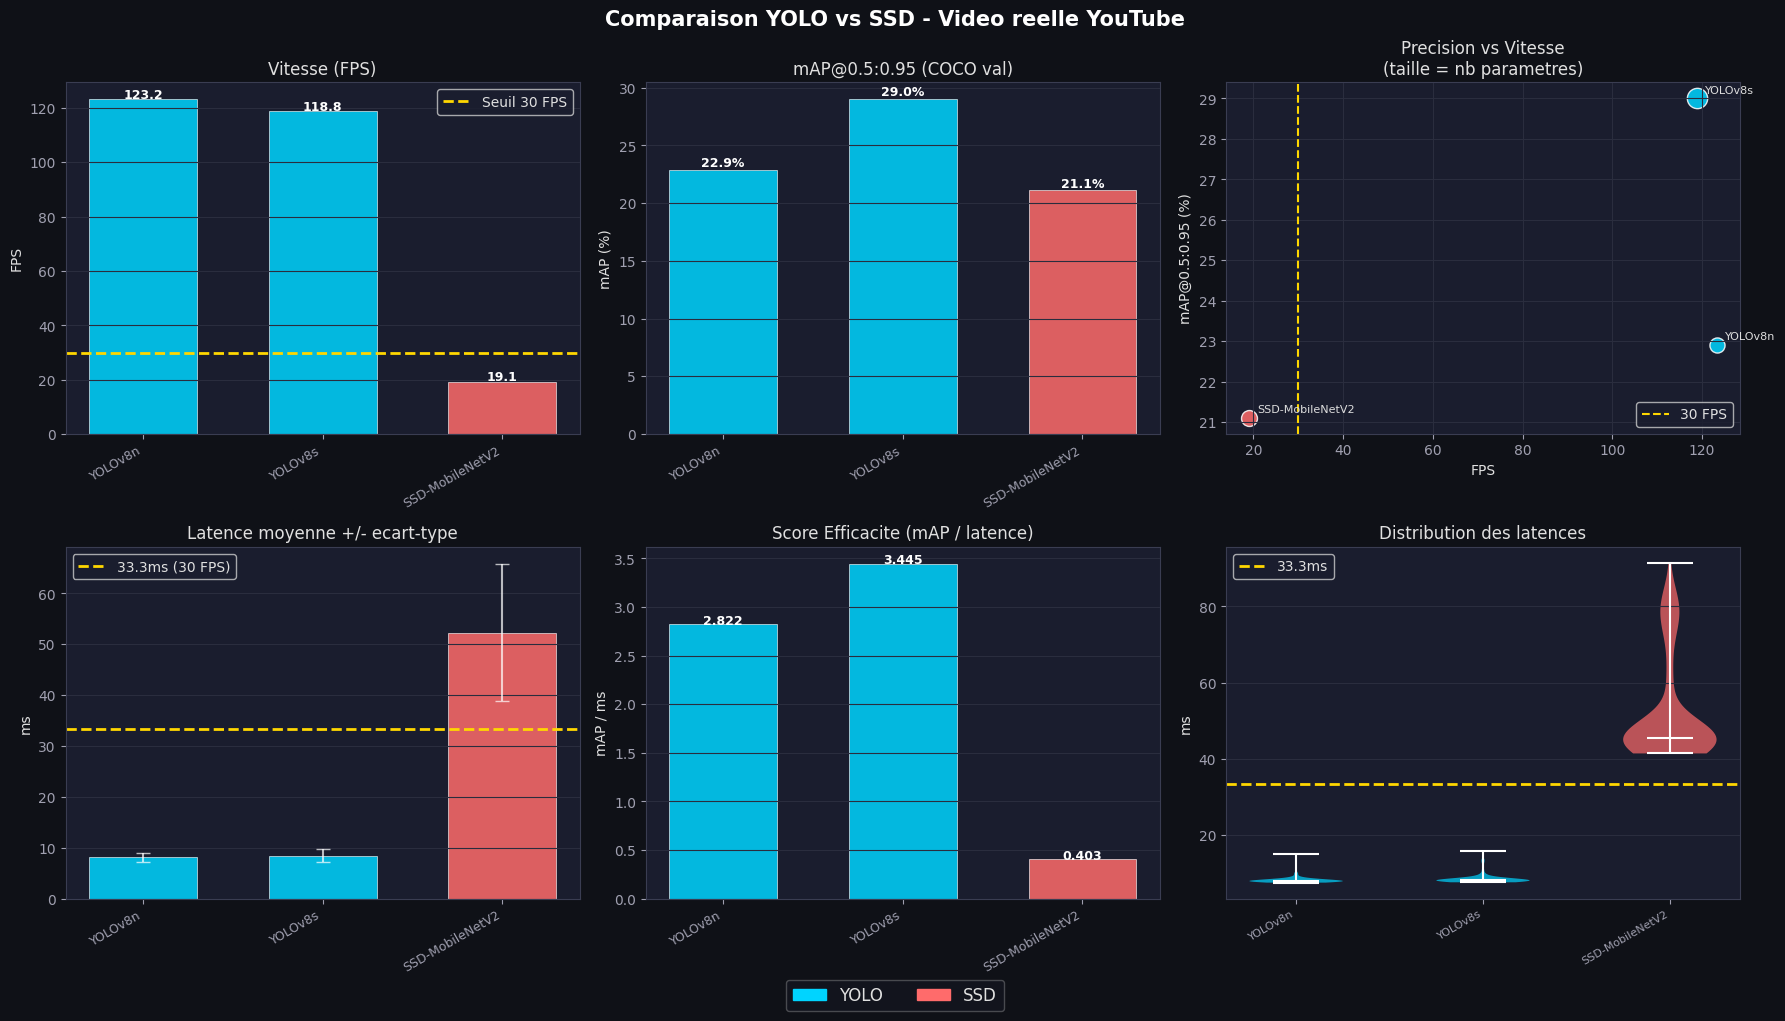

Figure sauvegardee: yolo_ssd_comparison.png


In [8]:
# Visualisations
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d2e',
    'axes.edgecolor'  : '#3a3d52', 'axes.labelcolor': '#e0e0e0',
    'xtick.color'     : '#a0a0b0', 'ytick.color'    : '#a0a0b0',
    'text.color'      : '#e0e0e0', 'grid.color'     : '#2a2d3e',
})

COLORS = {'YOLO': '#00d4ff', 'SSD': '#ff6b6b'}
colors = [COLORS[t] for t in df['type']]
x      = np.arange(len(df))
models = df['model'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Comparaison YOLO vs SSD - Video reelle YouTube',
             fontsize=15, fontweight='bold', color='white')

# 1. FPS
ax   = axes[0, 0]
bars = ax.bar(x, df['fps'], color=colors, alpha=0.85, width=0.6,
              edgecolor='white', lw=0.5)
ax.axhline(30, color='#ffd700', ls='--', lw=2, label='Seuil 30 FPS')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('FPS')
ax.set_title('Vitesse (FPS)')
ax.legend()
ax.grid(axis='y')
for b, v in zip(bars, df['fps']):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
            f'{v:.1f}', ha='center', fontsize=9, color='white', fontweight='bold')

# 2. mAP@0.5:0.95
ax   = axes[0, 1]
bars = ax.bar(x, df['map50_95'], color=colors, alpha=0.85, width=0.6,
              edgecolor='white', lw=0.5)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('mAP (%)')
ax.set_title('mAP@0.5:0.95 (COCO val)')
ax.grid(axis='y')
for b, v in zip(bars, df['map50_95']):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
            f'{v:.1f}%', ha='center', fontsize=9, color='white', fontweight='bold')

# 3. Scatter FPS vs mAP
ax = axes[0, 2]
for _, row in df.iterrows():
    c = COLORS[row['type']]
    ax.scatter(row['fps'], row['map50_95'],
               s=row['params_M']*12+80, color=c, alpha=0.85, edgecolors='white', lw=1)
    ax.annotate(row['model'], (row['fps'], row['map50_95']),
                textcoords='offset points', xytext=(6, 4), fontsize=8, color='#ddd')
ax.axvline(30, color='#ffd700', ls='--', lw=1.5, label='30 FPS')
ax.set_xlabel('FPS')
ax.set_ylabel('mAP@0.5:0.95 (%)')
ax.set_title('Precision vs Vitesse\n(taille = nb parametres)')
ax.legend()
ax.grid()

# 4. Latence avec ecart-type
ax = axes[1, 0]
ax.bar(x, df['avg_latency_ms'], color=colors, alpha=0.85, width=0.6,
       yerr=df['std_latency_ms'], capsize=5, edgecolor='white', lw=0.5,
       error_kw={'ecolor': 'white', 'alpha': 0.7})
ax.axhline(1000/30, color='#ffd700', ls='--', lw=2, label='33.3ms (30 FPS)')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('ms')
ax.set_title('Latence moyenne +/- ecart-type')
ax.legend()
ax.grid(axis='y')

# 5. Score efficacite
ax   = axes[1, 1]
bars = ax.bar(x, df['efficiency'], color=colors, alpha=0.85, width=0.6,
              edgecolor='white', lw=0.5)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('mAP / ms')
ax.set_title('Score Efficacite (mAP / latence)')
ax.grid(axis='y')
for b, v in zip(bars, df['efficiency']):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.001,
            f'{v:.3f}', ha='center', fontsize=9, color='white', fontweight='bold')

# 6. Distribution des latences
ax        = axes[1, 2]
all_times = [r['frame_times'] for r in results]
all_cols  = [COLORS[r['type']] for r in results]
parts     = ax.violinplot(all_times, positions=range(len(all_times)), showmedians=True)
for pc, col in zip(parts['bodies'], all_cols):
    pc.set_facecolor(col)
    pc.set_alpha(0.7)
for key in ['cmedians', 'cbars', 'cmaxes', 'cmins']:
    parts[key].set_color('white')
ax.axhline(1000/30, color='#ffd700', ls='--', lw=2, label='33.3ms')
ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('ms')
ax.set_title('Distribution des latences')
ax.legend()
ax.grid(axis='y')

fig.legend(
    handles=[mpatches.Patch(color='#00d4ff', label='YOLO'),
             mpatches.Patch(color='#ff6b6b', label='SSD')],
    loc='lower center', ncol=2, framealpha=0.3,
    fontsize=12, bbox_to_anchor=(0.5, -0.03)
)

plt.tight_layout()
plt.savefig('yolo_ssd_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Figure sauvegardee: yolo_ssd_comparison.png')

In [9]:
# Restaurer YOLO en FP32
device = 'cuda' if torch.cuda.is_available() else 'cpu'
for name, model in models_yolo.items():
    model.model.float()
    model.model.to(device)
    print(f'{name} restaure en FP32 sur {device}')

YOLOv8n restaure en FP32 sur cuda
YOLOv8s restaure en FP32 sur cuda


In [10]:
# Video annotee YOLO
def annotate_video_yolo(model, video_path, output_path, model_name,
                         conf=0.30, max_frames=300):
    cap     = cv2.VideoCapture(video_path)
    fps_src = cap.get(cv2.CAP_PROP_FPS)
    w       = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h       = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    out     = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*'mp4v'),
                               fps_src, (w, h))
    device      = 'cuda' if torch.cuda.is_available() else 'cpu'
    np.random.seed(42)
    palette     = np.random.randint(50, 255, (100, 3)).tolist()
    fps_hist    = []
    frame_count = 0

    while cap.isOpened() and frame_count < max_frames:
        ret, frame = cap.read()
        if not ret:
            break

        t0      = time.perf_counter()
        results = model(frame, device=device, conf=conf, verbose=False)
        t1      = time.perf_counter()

        fps_inst = 1.0 / (t1 - t0)
        fps_hist.append(fps_inst)
        fps_avg = np.mean(fps_hist[-20:])

        boxes = results[0].boxes
        n_det = 0
        if boxes is not None:
            for box in boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
                cls_id = int(box.cls[0].item())
                conf_v = box.conf[0].item()
                label  = COCO_LABELS[cls_id] if cls_id < len(COCO_LABELS) else f'cls{cls_id}'
                color  = tuple(palette[cls_id % len(palette)])
                cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
                text = f'{label} {conf_v:.2f}'
                (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 1)
                cv2.rectangle(frame, (x1, y1-th-8), (x1+tw+4, y1), color, -1)
                cv2.putText(frame, text, (x1+2, y1-4),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1)
                n_det += 1

        overlay = frame.copy()
        cv2.rectangle(overlay, (0, 0), (280, 80), (0, 0, 0), -1)
        cv2.addWeighted(overlay, 0.5, frame, 0.5, 0, frame)
        fps_color = (0, 255, 80) if fps_avg >= 30 else (0, 100, 255)
        cv2.putText(frame, f'Model: {model_name}',
                    (8, 22), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 200), 1)
        cv2.putText(frame, f'FPS: {fps_avg:.1f}',
                    (8, 48), cv2.FONT_HERSHEY_SIMPLEX, 0.75, fps_color, 2)
        cv2.putText(frame, f'Frame {frame_count+1}/{max_frames}  Det: {n_det}',
                    (8, 70), cv2.FONT_HERSHEY_SIMPLEX, 0.42, (180, 180, 180), 1)

        out.write(frame)
        frame_count += 1

    cap.release()
    out.release()
    print(f'Termine : {output_path} | FPS moyen: {np.mean(fps_hist):.1f}')

for name, model in models_yolo.items():
    annotate_video_yolo(model, VIDEO_PATH, f'output_{name}.mp4', name)

Termine : output_YOLOv8n.mp4 | FPS moyen: 121.1
Termine : output_YOLOv8s.mp4 | FPS moyen: 102.3


In [11]:
# Video annotee SSD
def annotate_video_ssd(detector, video_path, output_path, model_name,
                        conf=0.45, nms_threshold=0.35, max_frames=300):
    cap     = cv2.VideoCapture(video_path)
    fps_src = cap.get(cv2.CAP_PROP_FPS)
    w       = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h       = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    out     = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*'mp4v'),
                               fps_src, (w, h))
    np.random.seed(42)
    palette     = np.random.randint(50, 255, (100, 3)).tolist()
    fps_hist    = []
    frame_count = 0

    while cap.isOpened() and frame_count < max_frames:
        ret, frame = cap.read()
        if not ret:
            break

        img_rgb    = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        img_tensor = tf.convert_to_tensor(img_rgb)[tf.newaxis, ...]

        t0     = time.perf_counter()
        result = detector(img_tensor)
        t1     = time.perf_counter()

        fps_inst = 1.0 / (t1 - t0)
        fps_hist.append(fps_inst)
        fps_avg = np.mean(fps_hist[-20:])

        boxes_tf   = result['detection_boxes'][0].numpy()
        scores_tf  = result['detection_scores'][0].numpy()
        classes_tf = result['detection_classes'][0].numpy().astype(int)

        # Filtrer par seuil de confiance
        valid_boxes, valid_scores, valid_cls = [], [], []
        for i in range(len(scores_tf)):
            if scores_tf[i] < conf:
                continue
            label_idx = classes_tf[i] - 1
            if label_idx < 0 or label_idx >= len(COCO_LABELS):
                continue
            x1 = float(boxes_tf[i][1])
            y1 = float(boxes_tf[i][0])
            bw = float(boxes_tf[i][3] - boxes_tf[i][1])
            bh = float(boxes_tf[i][2] - boxes_tf[i][0])
            if bw < 0.01 or bh < 0.01:
                continue
            valid_boxes.append([x1, y1, bw, bh])
            valid_scores.append(float(scores_tf[i]))
            valid_cls.append(classes_tf[i])

        n_det = 0
        if len(valid_boxes) > 0:
            indices_nms = cv2.dnn.NMSBoxes(
                valid_boxes, valid_scores,
                score_threshold=conf,
                nms_threshold=nms_threshold
            )
            if len(indices_nms) > 0:
                for idx in indices_nms.flatten():
                    score     = valid_scores[idx]
                    cls_id    = valid_cls[idx]
                    label_idx = cls_id - 1
                    box       = valid_boxes[idx]

                    x1 = max(0, int(box[0] * w))
                    y1 = max(0, int(box[1] * h))
                    x2 = min(w, int((box[0] + box[2]) * w))
                    y2 = min(h, int((box[1] + box[3]) * h))

                    if (x2 - x1) < 15 or (y2 - y1) < 15:
                        continue

                    label = COCO_LABELS[label_idx]
                    color = tuple(palette[cls_id % len(palette)])

                    cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
                    text = f'{label} {score:.2f}'
                    (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 1)
                    cv2.rectangle(frame, (x1, y1-th-8), (x1+tw+4, y1), color, -1)
                    cv2.putText(frame, text, (x1+2, y1-4),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1)
                    n_det += 1

        overlay = frame.copy()
        cv2.rectangle(overlay, (0, 0), (280, 80), (0, 0, 0), -1)
        cv2.addWeighted(overlay, 0.5, frame, 0.5, 0, frame)
        fps_color = (0, 255, 80) if fps_avg >= 30 else (0, 100, 255)
        cv2.putText(frame, f'Model: {model_name}',
                    (8, 22), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 200), 1)
        cv2.putText(frame, f'FPS: {fps_avg:.1f}',
                    (8, 48), cv2.FONT_HERSHEY_SIMPLEX, 0.75, fps_color, 2)
        cv2.putText(frame, f'Frame {frame_count+1}/{max_frames}  Det: {n_det}',
                    (8, 70), cv2.FONT_HERSHEY_SIMPLEX, 0.42, (180, 180, 180), 1)

        out.write(frame)
        frame_count += 1

    cap.release()
    out.release()
    print(f'Termine : {output_path} | FPS moyen: {np.mean(fps_hist):.1f}')


if ssd_tf_hub is not None:
    annotate_video_ssd(
        ssd_tf_hub, VIDEO_PATH,
        'output_SSD_MobileNetV2.mp4',
        'SSD-MobileNetV2',
        conf=0.45,
        nms_threshold=0.35
    )
else:
    print('SSD non disponible - relancer la cellule 5')

Termine : output_SSD_MobileNetV2.mp4 | FPS moyen: 20.0


In [12]:
# Telecharger tous les fichiers
from google.colab import files

output_files = [
    'output_YOLOv8n.mp4',
    'output_YOLOv8s.mp4',
    'output_SSD_MobileNetV2.mp4',
    'yolo_ssd_comparison.png',
    'benchmark_results.csv',
]

for f in output_files:
    if os.path.exists(f):
        size = os.path.getsize(f) / 1e6
        print(f'Telechargement: {f}  ({size:.1f} MB)')
        files.download(f)
    else:
        print(f'Non trouve: {f}')

Telechargement: output_YOLOv8n.mp4  (4.6 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Telechargement: output_YOLOv8s.mp4  (4.6 MB)


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Telechargement: benchmark_results.csv  (0.0 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>